<a href="https://colab.research.google.com/github/roldannahuelalejadro/Fisica-de-Fluidos-E1/blob/main/Copia_de_P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema 4: Estimación de parámetros con PINNs**

Un grupo de Laboratorio 5 elige hacer la mejor práctica de la materia: Fluidos.
En esta práctica, se introduce un agitador magnético para generar un vórtice dentro de un recipiente cilíndrico y se usa el método velocimetría de imágenes de partículas (PIV, por sus siglas en inglés).
Esto permite medir el campo de velocidades $\mathbf{u}(\mathbf{x}, t)$ sobre la superficie, habitualmente modelado mediante el vórtice de Burgers
$$ \mathbf{u}_B(\mathbf{x}, t) = -\alpha r \mathbf{\hat{r}} + \frac{\Gamma}{2\pi r}\left[1 - \exp\left(-r^2/r_0^2\right)\right]\boldsymbol{\hat{\theta}} + 2\alpha z\mathbf{\hat{z}} $$

donde $\Gamma$ es la circulación asintótica del vórtice, $\alpha$ un parámetro que controla el flujo radial y $r_0 = \alpha / 2\nu$ un radio característico del vórtice controlado por la velocidad y la viscosidad.
Dado que se mira la superficie, la componente $z$ suele ignorarse por completo.

Sin embargo, las cámaras de alta velocidad necesarias para hacer PIV no funcionan y no pudieron ser reemplazadas por cuestiones presupuestarias. Ante la desesperación, el grupo decide introducir una pequeña bolita de polietileno dentro del flujo y grabarla con un celular.
Luego, el grupo elige algunos de los cuadros del video donde tanto el centro del vórtice cómo la bolita se ven claramente y, muy laboriosamente, determinan la posición relativa de ambos.
Estos datos se encuentran en el archivo `posiciones.txt`, con la posición $\mathbf{X}(t)$ (en cartesianas) de la boltia respecto al vórtice (que se considera en el origen) para los $t$ indicados. Las distancias están medidas en centimetros y el tiempo en segundos.

Entrene una PINN que ajuste la trayectoria mediante el modelo de Burgers $\dot{\mathbf{X}} = \mathbf{u}_B(\mathbf{X}, t)$ y aprenda los parámetros $\alpha$, $\Gamma$ y $r_0$. La predicción de la PINN debe coincidir con los datos provistos en una trayectoria aproximadamente espiralada, cómo mínimo. Puede usar el siguiente esqueleto, que además contiene estimaciones del orden de magnitud de los distintos parámetros hechos por el grupo. Los parámetros propuestos no son necesariamente óptimos, es libre de cambiarlos todos.

**Nota:** Por simplicidad, ignoraremos los errores en la medición de estos datos, pero podrían incluirse cómo un término adicional de la función de pérdida.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Cargar datos
!pip install -q gdown
!gdown 1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD -O posiciones.txt

t_data, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)



Downloading...
From: https://drive.google.com/uc?id=1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD
To: /content/posiciones.txt
100% 1.52k/1.52k [00:00<00:00, 4.74MB/s]


 Este problema es ligereamente distinto al resto, ya que se nos presenta una
serie de datos que son los que obtuvo el grupo de laboratorio expuestos en el archivo "posiciones.txt", y usaremos la red neuronal para que ajuste los parámetros fisicos $(\alpha, \Gamma, r_0)$
uniendo los datos con trayectorias que satisfagan las ecuaciones diferenciales.
Comenzamos llamando las librerías necesarias y definiendo nuestra PINN a través de $classPINN$ reutilizando el esqueleto del código del punto anterior.
Como se comentó anteriormente, buscamos entrenar a nuestra red minimizando una funcion que llamamos la "funcion de perdida total" denotada por $\mathcal{L}$, la cual se define como:
 $$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda\,\mathcal{L}_{\text{phys}}$$

En éste caso nuestra entrada está definida por una neurona, que corresponde a la unica variable independiente, el **tiempo**. Se definió en la parte de ***"hidden sizes***" las capas ocultas, que estan compuestas por 3 etapas cada una con 32 neuronas las cuales son las que entrenaremos, y por ultimo contamos con la salida que es bidimensional con 2 neuronas que corresponden a las variables en polares ($r(t); \theta(t)$).

Luego viene una parte de crucial importancia, como mencionamos antes los parametros que queremos ajustar son $$(\alpha, \Gamma, r_0)$$ por lo tanto, estas cantidades **NO** deben estar igualadas a alguna cantidad ya que sino el codigo las contemplaría como fijas. Para este problema precisamente, buscamos variar estas cantidades para que se ajusten a nuestro modelo fisico descrito por las ecuaciones diferenciales. En el código se expresa entre cortchetes [] el valor inicial de estas cantidades en torno a las que el programa las ajustará.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

#Vengo con la PINN del P3 y le hago modificaciones
class PINN(torch.nn.Module):
    def __init__(self, hidden_sizes=[32,32,32]):
        super().__init__()
        layers = [1] + hidden_sizes + [2] #le doy 2 parametros de salida, r y theta
        self.layers = torch.nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(torch.nn.Linear(layers[i], layers[i+1]))

        self.alpha=torch.nn.Parameter(torch.tensor([0.1]))
        self.Gamma=torch.nn.Parameter(torch.tensor([10.0]))
        self.r0=torch.nn.Parameter(torch.tensor([1.0]))

        self.loss_history=[]
        self.loss_data_history=[]
        self.loss_phys_history=[]

    def forward(self,t):
        x=t
        for layer in self.layers[:-1]: x=torch.sigmoid(layer(x))
        return self.layers[-1](x)


    def data_loss(self,t_data,rtheta_data):
        return torch.mean((self.forward(t_data)-rtheta_data)**2)

    def burgers_rhs(self,r):
        drdt=-self.alpha*r
        dthetadt=(self.Gamma/(2*torch.pi*r**2))*(1-torch.exp(-(r**2)/(self.r0**2)))
        return drdt,dthetadt

    def physics_loss(self,t_phys):
        t_phys=t_phys.requires_grad_(True)

        pred=self.forward(t_phys)
        r=pred[:,0:1]
        theta=pred[:,1:2]

        drdt=torch.autograd.grad(
            r,t_phys,
            grad_outputs=torch.ones_like(r),
            create_graph=True
        )[0]

        dthetadt=torch.autograd.grad(
            theta,t_phys,
            grad_outputs=torch.ones_like(theta),
            create_graph=True
        )[0]

        drdt_rhs,dthetadt_rhs=self.burgers_rhs(r)

        res_r=drdt-drdt_rhs
        res_theta=dthetadt-dthetadt_rhs

        return torch.mean(res_r**2+res_theta**2)

    def total_loss(self,t_data,rtheta_data,t_phys,lambda_phys):
        ld=self.data_loss(t_data,rtheta_data)
        lp=self.physics_loss(t_phys)
        return ld+lambda_phys*lp,ld,lp

    def train_pinn(self,t_data,rtheta_data,t_phys,epochs=20000,lr=1e-3,lambda_phys=1e-2):
        optimizer=torch.optim.Adam(self.parameters(),lr=lr)
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss,ld,lp=self.total_loss(t_data,rtheta_data,t_phys,lambda_phys)
            loss.backward()
            optimizer.step()
            self.loss_history.append(loss.item())
            self.loss_data_history.append(ld.item())
            self.loss_phys_history.append(lp.item())
            if epoch%2000==0:
                print(f"epoch {epoch:5d} | total {loss.item():.3e} | data {ld.item():.3e} | phys {lp.item():.3e}")
        print("\nEntrenamiento terminado\n")
        print("alpha =",self.alpha.item())
        print("Gamma =",self.Gamma.item())
        print("r0 =",self.r0.item())

    def plot_loss(self):
        plt.figure(figsize=(8,5))
        plt.plot(self.loss_history,label="total")
        plt.plot(self.loss_data_history,label="data")
        plt.plot(self.loss_phys_history,label="physics")
        plt.yscale("log")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.legend()
        plt.grid()
        plt.show()


In [ ]:
t_data, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)

# Convierto a r(t), θ(t)

r_data = np.sqrt(x_data**2 + y_data**2)
theta_data = np.arctan2(y_data, x_data)

t_data = torch.tensor(t_data[:,None], dtype=torch.float32)
rtheta_data = torch.tensor(np.stack([r_data,theta_data],axis=1), dtype=torch.float32)

t_phys = torch.linspace(t_data.min(), t_data.max(), 200).reshape(-1,1)

In [ ]:
model = PINN([10,15,10])

model.train_pinn(
    t_data,
    rtheta_data,
    t_phys,
    epochs=20000,
    lr=1e-3,
    lambda_phys=1e-3
)

model.plot_loss()

epoch     0 | total 9.632e+00 | data 9.630e+00 | phys 2.376e+00
epoch  2000 | total 1.719e+00 | data 1.719e+00 | phys 1.416e-02


KeyboardInterrupt: 

In [ ]:
with torch.no_grad():

    pred = model.forward(t_data)

r_pred = pred[:,0].numpy()
theta_pred = pred[:,1].numpy()

x_pred = r_pred*np.cos(theta_pred)
y_pred = r_pred*np.sin(theta_pred)

plt.figure(figsize=(6,6))

plt.plot(x_data, y_data, 'o-', label="Datos", alpha=0.7)
plt.plot(x_pred, y_pred, '-', label="PINN", linewidth=2)

plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Trayectoria de la partícula en el vórtice")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

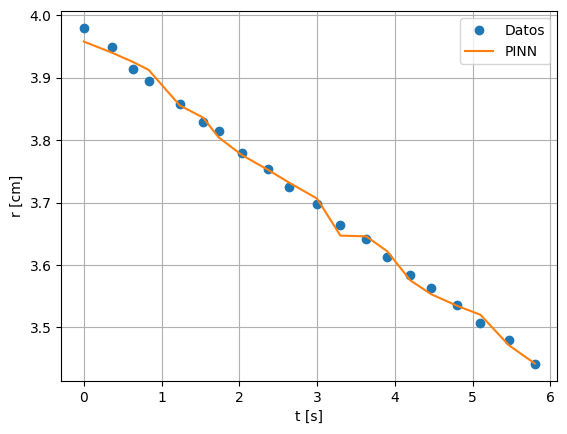

In [ ]:
plt.figure()

plt.plot(t_data.numpy(), r_data, 'o', label="Datos")
plt.plot(t_data.numpy(), r_pred, '-', label="PINN")

plt.xlabel("t [s]")
plt.ylabel("r [cm]")
plt.grid(True)
plt.legend()

plt.show()

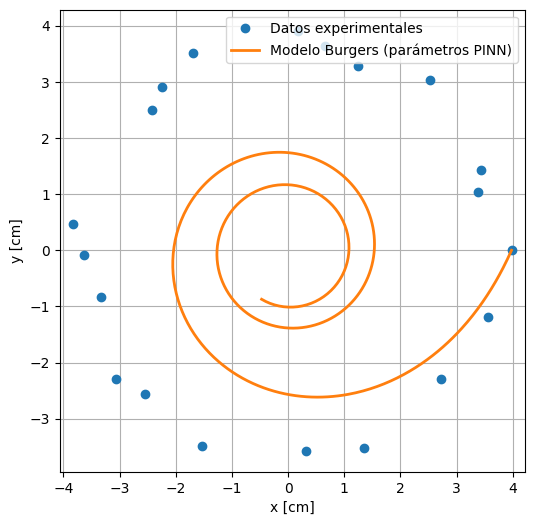

In [ ]:
alpha = model.alpha.item()
Gamma = model.Gamma.item()
r0 = model.r0.item()

t_sim = np.linspace(t_data[0].item(), 10*t_data[-1].item(), 400)

dt = t_sim[1]-t_sim[0]

r_sim = np.zeros_like(t_sim)
theta_sim = np.zeros_like(t_sim)

r_sim[0] = r_data[0]
theta_sim[0] = theta_data[0]

for i in range(len(t_sim)-1):

    r = r_sim[i]

    drdt = -alpha*r
    dthetadt = (Gamma/(2*np.pi*r**2))*(1-np.exp(-(r**2)/(r0**2)))

    r_sim[i+1] = r + drdt*dt

    theta_sim[i+1] = theta_sim[i] + dthetadt*dt

x_sim = r_sim*np.cos(theta_sim)
y_sim = r_sim*np.sin(theta_sim)

plt.figure(figsize=(6,6))

plt.plot(x_data, y_data, 'o', label="Datos experimentales")
plt.plot(x_sim, y_sim, '-', label="Modelo Burgers (parámetros PINN)", linewidth=2)

plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()